In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/javeriaismail99/wholesale-customer-data/Wholesale customers data.csv


In [2]:
#DATA LOADING
import pandas as pd
DATA_PATH = "/kaggle/input/datasets/javeriaismail99/wholesale-customer-data/Wholesale customers data.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape); print(df.head())

(440, 8)
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


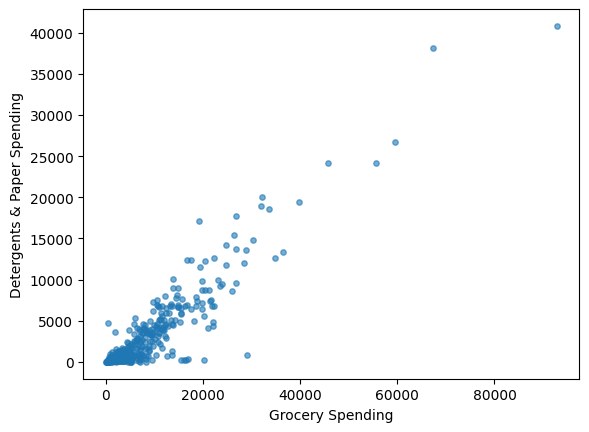

In [3]:
#VISUALIZATION
import matplotlib.pyplot as plt
plt.scatter(df["Grocery"], df["Detergents_Paper"], s=15, alpha=0.6)
plt.xlabel("Grocery Spending"); plt.ylabel("Detergents & Paper Spending"); plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
feature_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
X_scaled = StandardScaler().fit_transform(df[feature_cols].values)

In [5]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [6]:
df["Cluster"] = kmeans.predict(X_scaled)
print(df["Cluster"].value_counts())

Cluster
1    393
0     45
2      2
Name: count, dtype: int64


In [7]:
comparison = pd.crosstab(df["Cluster"], df["Channel"])
print(comparison)

Channel    1   2
Cluster         
0          1  44
1        295  98
2          2   0
